In [1]:
library(Seurat)
library(scattermore)
library(data.table)
library(patchwork)
library(arrow)
options(future.globals.maxSize = 1000 * 1024^2)
options(Seurat.object.assay.version = "v4")
library(tidyverse)
library(cowplot)
library(patchwork)
library(WGCNA)
library(hdWGCNA)
library(ggplot2)
library(dplyr)
library(ggrepel) 
library(tidygraph)
library(ggraph)
library(igraph)
# enable parallel processing for network analysis 
enableWGCNAThreads(nThreads = 12)

# using the cowplot theme for ggplot
theme_set(theme_cowplot())

# set random seed for reproducibility
set.seed(12345)

Attaching SeuratObject

‘SeuratObject’ was built under R 4.3.1 but the current version is
4.3.3; it is recomended that you reinstall ‘SeuratObject’ as the ABI
for R may have changed

‘SeuratObject’ was built with package ‘Matrix’ 1.6.1.1 but the current
version is 1.6.5; it is recomended that you reinstall ‘SeuratObject’ as
the ABI for ‘Matrix’ may have changed

Seurat v4 was just loaded with SeuratObject v5; disabling v5 assays and
validation routines, and ensuring assays work in strict v3/v4
compatibility mode


Attaching package: ‘arrow’


The following object is masked from ‘package:utils’:

    timestamp


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   4.0.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::between()      masks data.t

Allowing parallel execution with up to 12 working processes.


In [2]:
combined_obj <- readRDS("../Data/GSE280318_hdWGCNA.rds")


In [ ]:
library(STRINGdb)
string_db <- STRINGdb$new(version = "12.0", species = 9606, 
                          score_threshold = 400, input_directory = "")
gene_df <- data.frame(gene_name = rownames(combined_obj))
mapped_genes <- string_db$map(gene_df, "gene_name", removeUnmappedRows = TRUE)
mapped_genes$STRING_id <- stringr::str_replace(mapped_genes$STRING_id, '9606.', '')


In [4]:
# retrieve the full PPI graph as an igraph object
options(timeout = 1800)
options(download.file.method = "libcurl")
ppi <- string_db$get_graph()

# remove the Taxonomy ID from the protein names
ppi <- igraph::set_vertex_attr(
    ppi, 'name', 
    value=stringr::str_replace(names(V(ppi)), '9606.', '')
)
ens_df <- subset(
    mapped_genes, 
    STRING_id %in% names(V(ppi))
)
# subset the PPI network to just proteins found in our Ensembl data
ppi <- igraph::subgraph(
    ppi,
    vids = unique(ens_df$STRING_id)
)

# match the protein names w/ gene names, update the PPI network
ix <- match(names(V(ppi)), ens_df$STRING_id)
ppi <- igraph::set_vertex_attr(
    ppi, 'name', 
    value=ens_df$gene_name[ix]
)
head(names(V(ppi)))


[1] "ARF5"    "M6PR"    "CYP26B1" "NDUFAF7" "FUCA2"   "HS3ST1"

In [5]:
# keep genes that are in the co-expression network and in the PPI network
keep_genes <- GetWGCNAGenes(combined_obj)
keep_genes <- keep_genes[keep_genes %in% names(V(ppi))]

# subset the PPI network
ppi <- igraph::subgraph(
    ppi,
    vids = keep_genes
)

# get the adjacency matrix representation of the PPI and
# binarize the matrix so 0 means no PPI, 1 means PPI 
ppi_mat <- igraph::as_adjacency_matrix(ppi, sparse=TRUE)
ppi_mat[ppi_mat > 0] <- 1

# get the coex network (TOM), 
TOM <- GetTOM(combined_obj)
TOM <- TOM[rownames(ppi_mat), colnames(ppi_mat)]
# perform element-wise multiplicaiton of the TOM by the PPIs network 
# to only retain gene-gene links supported by PPIs
TOM_ppi <- TOM * as.vector(ppi_mat)

# get modules and from the seurat obj
modules <- GetModules(combined_obj) %>% 
  subset(module != 'grey' & gene_name %in% keep_genes) %>%  
  mutate(module = droplevels(module))
mods <- levels(modules$module)

# get module colors for plotting 
mod_colors <- dplyr::select(modules, c(module, color)) %>% distinct()
mod_cp <- mod_colors$color; names(mod_cp) <- as.character(mod_colors$module)

Loading required package: ggrastr



[1] "plot_df:"
    Var1   Var2 value
2 COL1A2 COL1A1     0
3   MMP2 COL1A1     0
4  SPARC COL1A1     0
5 COL6A3 COL1A1     0
6 COL5A1 COL1A1     0
7  THBS2 COL1A1     0
[1] "plot_df:"
    Var1   Var2 value
2 COL1A2 COL1A1     0
3   MMP2 COL1A1     0
4  SPARC COL1A1     0
5 COL6A3 COL1A1     0
6 COL5A1 COL1A1     0
7  THBS2 COL1A1     0


Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


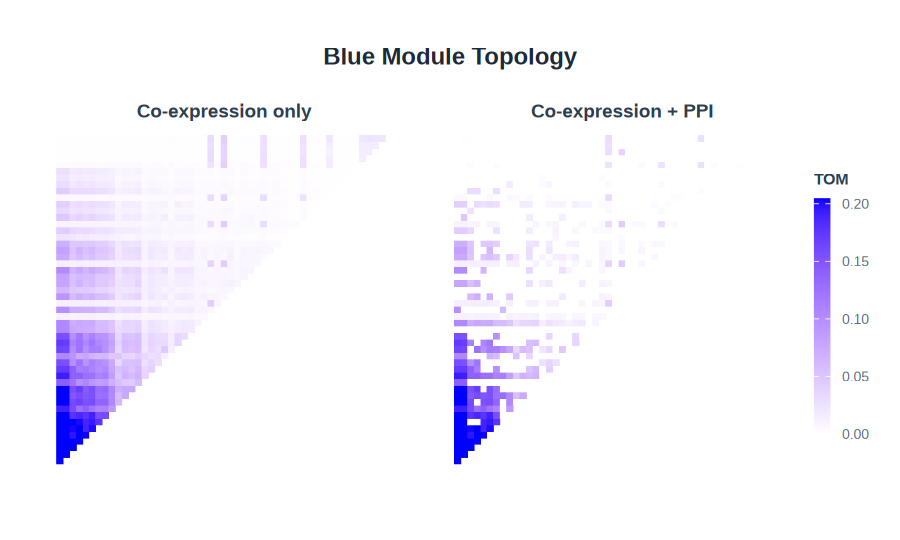

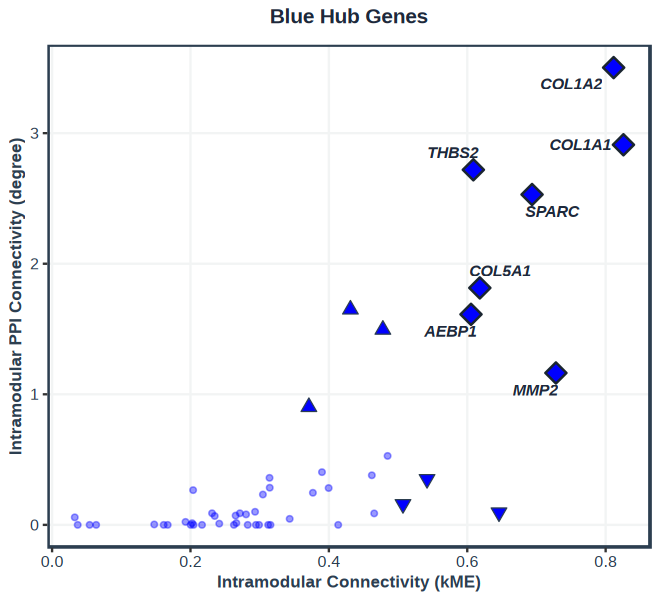

In [6]:
options(repr.plot.width = 7.5, repr.plot.height = 4.5) 

cur_mod <- 'blue'
cur_color <- mod_cp[cur_mod]
formatted_mod_title <- paste0(toupper(substring(cur_mod, 1, 1)), substring(cur_mod, 2))

tmp <- ModuleTopologyHeatmap(
    combined_obj,
    mod = cur_mod,
    matrix = TOM,
    matrix_name = 'TOM',
    order_by = 'kME',
    high_color = cur_color,
    #type = 'unsigned',
    return_genes = TRUE 
) 

subplot_theme <- theme(
  plot.title = element_text(hjust = 0.5, face = "bold", size = 11, color = "#2C3E50", margin = margin(b = 8)),
  plot.margin = margin(t = 6, r = 10, b = 6, l = 10, unit = "pt")
)

p1 <- tmp[[1]] + 
  ggtitle('Co-expression only') + 
  NoLegend() + 
  subplot_theme


gene_list <- tmp[[2]]
p2 <- ModuleTopologyHeatmap(
    combined_obj,
    mod = cur_mod,
    matrix = TOM_ppi,
    matrix_name = 'TOM',
    order_by = 'kME',
    high_color = cur_color,
    #type = 'unsigned',
    plot_max = tmp$plot_max,
    genes_order = gene_list
) + 
  ggtitle('Co-expression + PPI') + 
  subplot_theme +
  theme(
    legend.title = element_text(size = 9, face = "bold", color = "#2C3E50"),
    legend.text = element_text(size = 8, color = "#5D6D7E"),
    legend.key.width = unit(0.35, "cm"),
    legend.key.height = unit(1.0, "cm")
  )

combined_heatmaps <- (p1 | p2) + 
  plot_annotation(
    title = paste(formatted_mod_title, "Module Topology"), 
    theme = theme(
      plot.title = element_text(
        hjust = 0.5, 
        face = "bold", 
        size = 14,             
        color = "#1E293B", 
        margin = margin(t = 10, b = 15) 
      )
    )
  )


combined_heatmaps


options(repr.plot.width = 5.5, repr.plot.height = 5.0) 

cur_genes <- modules %>% subset(module == cur_mod) %>% .$gene_name
kme_df <- GetHubGenes(combined_obj, n_hubs=Inf) %>% subset(gene_name %in% cur_genes)
rownames(kme_df) <- kme_df$gene_name

cur_TOM_ppi <- TOM_ppi[cur_genes, cur_genes] 
cur_TOM_ppi[lower.tri(cur_TOM_ppi)] <- 0 
cur_TOM_df <- reshape2::melt(cur_TOM_ppi) %>% subset(Var1 != Var2)

ppi_degree <- cur_TOM_df %>% 
    dplyr::group_by(Var1) %>% 
    dplyr::summarise(degree = sum(value)) %>%
    dplyr::mutate(weighted_degree = degree / max(degree)) %>%
    dplyr::arrange(-degree) %>% 
    dplyr::rename(gene_name = Var1) %>%
    as.data.frame() 
rownames(ppi_degree) <- ppi_degree$gene_name

kme_df$ppi_degree <- ppi_degree[kme_df$gene_name, 'degree']

n_genes <- 10
top_kme <- kme_df %>% filter(kME>0) %>% slice_max(order_by=kME, n=n_genes) %>% .$gene_name
top_ppi <- kme_df %>% filter(ppi_degree>0) %>% slice_max(order_by=ppi_degree, n=n_genes) %>% .$gene_name

top_both <- intersect(top_kme, top_ppi)
df_kme <- subset(kme_df, gene_name %in% top_kme & !(gene_name %in% top_both))
df_ppi <- subset(kme_df, gene_name %in% top_ppi & !(gene_name %in% top_both))
df_both <- subset(kme_df, gene_name %in% top_both)

v_line <- min(df_kme$kME)
h_line <- min(df_ppi$ppi_degree)
point_size <- 3.0
blue_df_both <- df_both

kme_df %>% subset(!(gene_name %in% c(top_kme, top_ppi))) %>%
    ggplot(aes(x = kME, y = ppi_degree)) + 
    geom_point(color = cur_color, size = 1.2, alpha = 0.4) +
    geom_point(
        data = df_kme, size = point_size,
        fill = cur_color, color = "#2C3E50", stroke = 0.4, shape = 25
    ) + 
    geom_point(
        data = df_ppi, size = point_size,
        fill = cur_color, color = "#2C3E50", stroke = 0.4, shape = 24
    ) + 
    geom_point(
        data = df_both, size = point_size * 1.4,
        fill = cur_color, color = "#1A2530", stroke = 0.8, shape = 23
    ) + 
    geom_text_repel(
        data = df_both,
        mapping = aes(label = gene_name),
        color = "#1E293B",
        size = 3.2,
        fontface = "bold.italic",         
        box.padding = unit(0.4, "lines"), 
        point.padding = unit(0.3, "lines"),
        segment.color = "#7F8C8D",        
        segment.size = 0.4,               
        segment.linetype = "solid",
        max.overlaps = 20
    ) +
    
    labs(
      x = "Intramodular Connectivity (kME)", 
      y = "Intramodular PPI Connectivity (degree)",
      title = paste(formatted_mod_title, "Hub Genes")
    ) + 
    
    theme_bw(base_size = 11) +
    theme(
        panel.grid.major = element_line(color = "#F2F4F4", size = 0.5), 
        panel.grid.minor = element_blank(),
        panel.border = element_rect(color = "#2C3E50", fill = NA, size = 1.0), 
        axis.text = element_text(color = "#2C3E50", size = 9.5),
        axis.title = element_text(face = "bold", color = "#2C3E50", size = 10),
        plot.title = element_text(hjust = 0.5, face = "bold", size = 12, color = "#1E293B", margin = margin(b = 10)),
        plot.background = element_blank()
    ) 

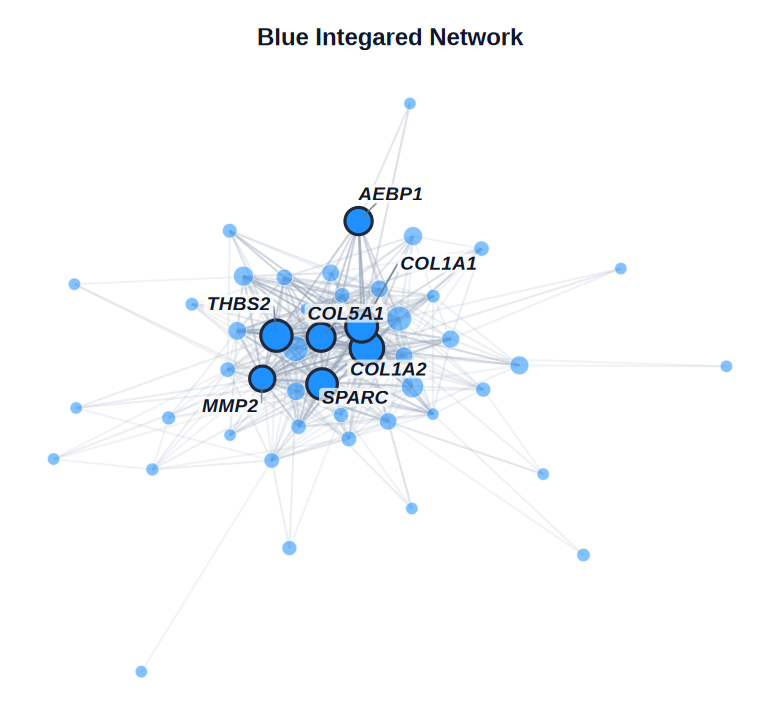

In [7]:
options(repr.plot.width = 6.5, repr.plot.height = 6.0) 

safe_scale01 <- function(x) {
  if (max(x, na.rm = TRUE) == min(x, na.rm = TRUE)) return(rep(1, length(x)))
  return((x - min(x, na.rm = TRUE)) / (max(x, na.rm = TRUE) - min(x, na.rm = TRUE)))
}

plot_list <- list()
mods <- 'blue'
for (cur_mod in mods) {
    
    cur_genes <- modules %>% subset(module == cur_mod) %>% .$gene_name

    kme_df <- GetHubGenes(combined_obj, n_hubs=Inf) %>%
        subset(gene_name %in% cur_genes)
    rownames(kme_df) <- kme_df$gene_name

    cur_TOM_ppi <- TOM_ppi[cur_genes, cur_genes] 
    cur_TOM_ppi[lower.tri(cur_TOM_ppi)] <- 0 

    cur_TOM_df <- reshape2::melt(cur_TOM_ppi) %>% subset(Var1 != Var2)

    ppi_degree <- cur_TOM_df %>% 
        dplyr::group_by(Var1) %>% 
        dplyr::summarise(degree = sum(value)) %>%
        dplyr::mutate(weighted_degree = degree / max(degree)) %>%
        dplyr::arrange(-degree) %>% 
        dplyr::rename(gene_name = Var1) %>%
        as.data.frame() 
    rownames(ppi_degree) <- ppi_degree$gene_name

    kme_df$ppi_degree <- ppi_degree[kme_df$gene_name, 'degree']

    # Top 10
    n_genes <- 10
    top_kme <- kme_df %>% filter(kME>0) %>% slice_max(order_by=kME, n=n_genes) %>% .$gene_name
    top_ppi <- kme_df %>% filter(ppi_degree>0) %>% slice_max(order_by=ppi_degree, n=n_genes) %>% .$gene_name
    top_both <- intersect(top_kme, top_ppi)
    graph <- cur_TOM_ppi %>% 
        reshape2::melt() %>% 
        dplyr::rename(gene1 = Var1, gene2 = Var2, weight=value) %>%
        subset(weight > 0) %>%
        igraph::graph_from_data_frame() %>%
        tidygraph::as_tbl_graph(directed=FALSE) %>% 
        tidygraph::activate(nodes)

    V(graph)$module <- modules[V(graph)$name, 'module']
    V(graph)$hub    <- ifelse(V(graph)$name %in% top_both, V(graph)$name, "")
    V(graph)$kME    <- kme_df[V(graph)$name, 'kME']
    V(graph)$ppi_degree <- kme_df[V(graph)$name, 'ppi_degree']


    ig_obj <- tidygraph::as.igraph(graph)
    

    coords <- tryCatch({
        igraph::layout_with_fr(ig_obj, weights = NA) 
    }, error = function(e) {
        igraph::layout_nicely(ig_obj)
    })
    
    coords <- scale(coords) * 1.5
    
    lay <- ggraph::create_layout(graph, layout = "manual", x = coords[, 1], y = coords[, 2])


    p <- ggraph(lay) + 
      
      geom_edge_link(
        aes(edge_alpha = safe_scale01(weight)), 
        color = "#94A3B8",        
        width = 0.45,
        show.legend = FALSE
      ) + 
      scale_edge_alpha_continuous(range = c(0.12, 0.80)) + 
      
      geom_node_point(
        aes(fill = module, size = ppi_degree), 
        shape = 21,
        color = "white",
        stroke = 0.3,
        alpha = 0.55,
        show.legend = FALSE
      ) +
      
      
      geom_node_point(
        data = subset(lay, hub != ''), 
        aes(fill = module, size = ppi_degree), 
        color = "#1E293B",        
        shape = 21, 
        stroke = 1.0,             
        alpha = 1.0,              
        show.legend = FALSE
      ) +
      
      scale_size_continuous(range = c(3, 8.5)) +
      scale_colour_manual(values = '#1E90FF') +
      scale_fill_manual(values = '#1E90FF') +
      
      geom_node_label(
        aes(label = hub), 
        repel = TRUE, 
        max.overlaps = 100,                     
        fontface = 'bold.italic',              
        size = 4,                            
        color = "#0F172A",                     
        fill = alpha("white", 0.70),           
        label.size = NA,                       
        label.padding = unit(0.12, "lines"),   
        box.padding = unit(0.65, "lines"),     
        point.padding = unit(0.40, "lines"),   
        segment.color = "#64748B",             
        segment.size = 0.35,
        segment.alpha = 0.8
      ) +
      
      labs(title = paste0(toupper(substring(cur_mod, 1, 1)), substring(cur_mod, 2), " Integared Network")) +
      theme_void() + 
      theme(
        plot.title = element_text(
          hjust = 0.5, 
          face = "bold", 
          size = 14, 
          color = "#0F172A", 
          margin = margin(t = 5, b = 15)
        ),
        plot.margin = margin(t = 12, r = 12, b = 12, l = 12, unit = "pt")
      )

    plot_list[[cur_mod]] <- p
}

plot_list[["blue"]]


[1] "plot_df:"
      Var1    Var2 value
2  CEACAM5 CEACAM6     0
3     CD24 CEACAM6     0
4      MYC CEACAM6     0
5 HSP90AA1 CEACAM6     0
6  LAPTM4B CEACAM6     0
7  S100A10 CEACAM6     0
[1] "plot_df:"
      Var1    Var2 value
2  CEACAM5 CEACAM6     0
3     CD24 CEACAM6     0
4      MYC CEACAM6     0
5 HSP90AA1 CEACAM6     0
6  LAPTM4B CEACAM6     0
7  S100A10 CEACAM6     0


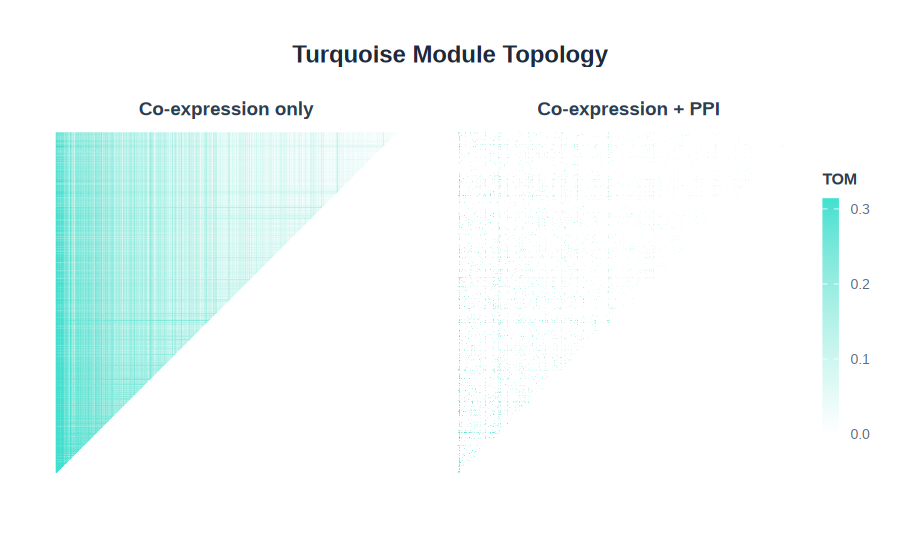

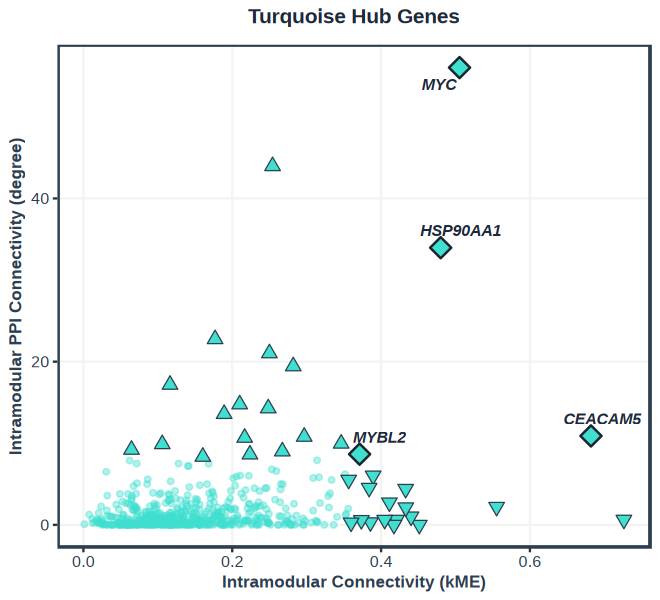

In [8]:
options(repr.plot.width = 7.5, repr.plot.height = 4.5) 

cur_mod <- 'turquoise'
cur_color <- mod_cp[cur_mod]
formatted_mod_title <- paste0(toupper(substring(cur_mod, 1, 1)), substring(cur_mod, 2))

tmp <- ModuleTopologyHeatmap(
    combined_obj,
    mod = cur_mod,
    matrix = TOM,
    matrix_name = 'TOM',
    order_by = 'kME',
    high_color = cur_color,
    #type = 'unsigned',
    return_genes = TRUE 
) 

subplot_theme <- theme(
  plot.title = element_text(hjust = 0.5, face = "bold", size = 11, color = "#2C3E50", margin = margin(b = 8)),
  plot.margin = margin(t = 6, r = 10, b = 6, l = 10, unit = "pt")
)

p1 <- tmp[[1]] + 
  ggtitle('Co-expression only') + 
  NoLegend() + 
  subplot_theme


gene_list <- tmp[[2]]
p2 <- ModuleTopologyHeatmap(
    combined_obj,
    mod = cur_mod,
    matrix = TOM_ppi,
    matrix_name = 'TOM',
    order_by = 'kME',
    high_color = cur_color,
    #type = 'unsigned',
    plot_max = tmp$plot_max,
    genes_order = gene_list
) + 
  ggtitle('Co-expression + PPI') + 
  subplot_theme +
  theme(
    legend.title = element_text(size = 9, face = "bold", color = "#2C3E50"),
    legend.text = element_text(size = 8, color = "#5D6D7E"),
    legend.key.width = unit(0.35, "cm"),
    legend.key.height = unit(1.0, "cm")
  )


combined_heatmaps <- (p1 | p2) + 
  plot_annotation(
    title = paste(formatted_mod_title, "Module Topology"), 
    theme = theme(
      plot.title = element_text(
        hjust = 0.5, 
        face = "bold", 
        size = 14,             
        color = "#1E293B", 
        margin = margin(t = 10, b = 15)
      )
    )
  )

combined_heatmaps


options(repr.plot.width = 5.5, repr.plot.height = 5.0) 

cur_genes <- modules %>% subset(module == cur_mod) %>% .$gene_name
kme_df <- GetHubGenes(combined_obj, n_hubs=Inf) %>% subset(gene_name %in% cur_genes)
rownames(kme_df) <- kme_df$gene_name

cur_TOM_ppi <- TOM_ppi[cur_genes, cur_genes] 
cur_TOM_ppi[lower.tri(cur_TOM_ppi)] <- 0 
cur_TOM_df <- reshape2::melt(cur_TOM_ppi) %>% subset(Var1 != Var2)

ppi_degree <- cur_TOM_df %>% 
    dplyr::group_by(Var1) %>% 
    dplyr::summarise(degree = sum(value)) %>%
    dplyr::mutate(weighted_degree = degree / max(degree)) %>%
    dplyr::arrange(-degree) %>% 
    dplyr::rename(gene_name = Var1) %>%
    as.data.frame() 
rownames(ppi_degree) <- ppi_degree$gene_name

kme_df$ppi_degree <- ppi_degree[kme_df$gene_name, 'degree']

n_genes <- 20
top_kme <- kme_df %>% filter(kME>0) %>% slice_max(order_by=kME, n=n_genes) %>% .$gene_name
top_ppi <- kme_df %>% filter(ppi_degree>0) %>% slice_max(order_by=ppi_degree, n=n_genes) %>% .$gene_name

top_both <- intersect(top_kme, top_ppi)
df_kme <- subset(kme_df, gene_name %in% top_kme & !(gene_name %in% top_both))
df_ppi <- subset(kme_df, gene_name %in% top_ppi & !(gene_name %in% top_both))
df_both <- subset(kme_df, gene_name %in% top_both)

v_line <- min(df_kme$kME)
h_line <- min(df_ppi$ppi_degree)
point_size <- 3.0
turquoise_df_both <- df_both
kme_df %>% subset(!(gene_name %in% c(top_kme, top_ppi))) %>%
    ggplot(aes(x = kME, y = ppi_degree)) + 
    geom_point(color = cur_color, size = 1.2, alpha = 0.4) + 
    geom_point(
        data = df_kme, size = point_size,
        fill = cur_color, color = "#2C3E50", stroke = 0.4, shape = 25
    ) + 
    
    geom_point(
        data = df_ppi, size = point_size,
        fill = cur_color, color = "#2C3E50", stroke = 0.4, shape = 24
    ) + 
    
    geom_point(
        data = df_both, size = point_size * 1.4,
        fill = cur_color, color = "#1A2530", stroke = 0.8, shape = 23
    ) + 
    
    geom_text_repel(
        data = df_both,
        mapping = aes(label = gene_name),
        color = "#1E293B",
        size = 3.2,
        fontface = "bold.italic",         
        box.padding = unit(0.4, "lines"), 
        point.padding = unit(0.3, "lines"),
        segment.color = "#7F8C8D",        
        segment.size = 0.4,               
        segment.linetype = "solid",
        max.overlaps = 20
    ) +
   
    labs(
      x = "Intramodular Connectivity (kME)", 
      y = "Intramodular PPI Connectivity (degree)",
      title = paste(formatted_mod_title, "Hub Genes")
    ) + 
    
    theme_bw(base_size = 11) +
    theme(
        panel.grid.major = element_line(color = "#F2F4F4", size = 0.5), 
        panel.grid.minor = element_blank(),
        panel.border = element_rect(color = "#2C3E50", fill = NA, size = 1.0), 
        axis.text = element_text(color = "#2C3E50", size = 9.5),
        axis.title = element_text(face = "bold", color = "#2C3E50", size = 10),
        plot.title = element_text(hjust = 0.5, face = "bold", size = 12, color = "#1E293B", margin = margin(b = 10)),
        plot.background = element_blank()
    ) 

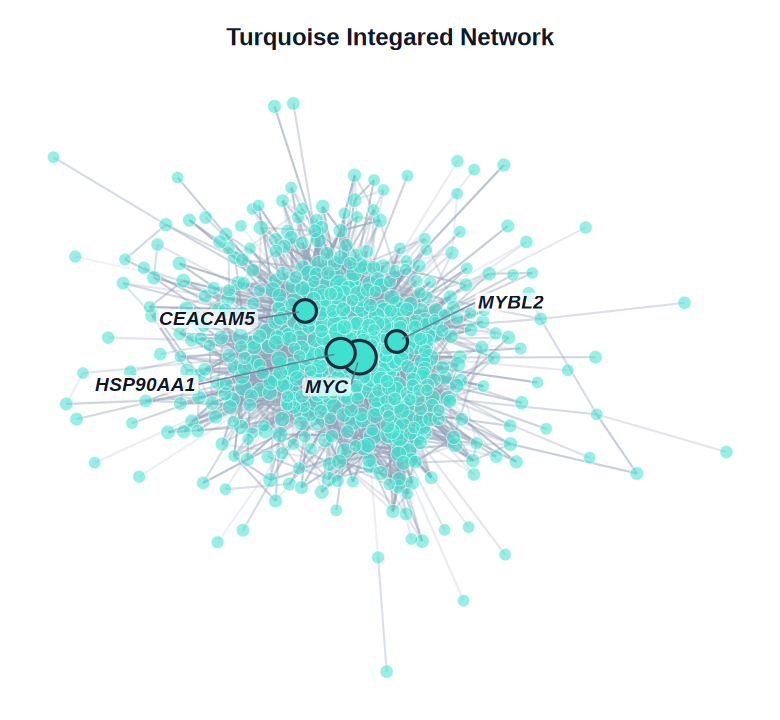

In [9]:
options(repr.plot.width = 6.5, repr.plot.height = 6.0) 

safe_scale01 <- function(x) {
  if (max(x, na.rm = TRUE) == min(x, na.rm = TRUE)) return(rep(1, length(x)))
  return((x - min(x, na.rm = TRUE)) / (max(x, na.rm = TRUE) - min(x, na.rm = TRUE)))
}

plot_list <- list()
mods <- 'turquoise'
for (cur_mod in mods) {
    
    cur_genes <- modules %>% subset(module == cur_mod) %>% .$gene_name

    kme_df <- GetHubGenes(combined_obj, n_hubs=Inf) %>%
        subset(gene_name %in% cur_genes)
    rownames(kme_df) <- kme_df$gene_name

    cur_TOM_ppi <- TOM_ppi[cur_genes, cur_genes] 
    cur_TOM_ppi[lower.tri(cur_TOM_ppi)] <- 0 

    cur_TOM_df <- reshape2::melt(cur_TOM_ppi) %>% subset(Var1 != Var2)

    ppi_degree <- cur_TOM_df %>% 
        dplyr::group_by(Var1) %>% 
        dplyr::summarise(degree = sum(value)) %>%
        dplyr::mutate(weighted_degree = degree / max(degree)) %>%
        dplyr::arrange(-degree) %>% 
        dplyr::rename(gene_name = Var1) %>%
        as.data.frame() 
    rownames(ppi_degree) <- ppi_degree$gene_name

    kme_df$ppi_degree <- ppi_degree[kme_df$gene_name, 'degree']

    n_genes <- 20
    top_kme <- kme_df %>% filter(kME>0) %>% slice_max(order_by=kME, n=n_genes) %>% .$gene_name
    top_ppi <- kme_df %>% filter(ppi_degree>0) %>% slice_max(order_by=ppi_degree, n=n_genes) %>% .$gene_name
    top_both <- intersect(top_kme, top_ppi)

    graph <- cur_TOM_ppi %>% 
        reshape2::melt() %>% 
        dplyr::rename(gene1 = Var1, gene2 = Var2, weight=value) %>%
        subset(weight > 0) %>%
        igraph::graph_from_data_frame() %>%
        tidygraph::as_tbl_graph(directed=FALSE) %>% 
        tidygraph::activate(nodes)

    V(graph)$module <- modules[V(graph)$name, 'module']
    V(graph)$hub    <- ifelse(V(graph)$name %in% top_both, V(graph)$name, "")
    V(graph)$kME    <- kme_df[V(graph)$name, 'kME']
    V(graph)$ppi_degree <- kme_df[V(graph)$name, 'ppi_degree']

    ig_obj <- tidygraph::as.igraph(graph)
    
    coords <- tryCatch({
        igraph::layout_with_fr(ig_obj, weights = NA) 
    }, error = function(e) {
        igraph::layout_nicely(ig_obj)
    })
    
    coords <- scale(coords) * 1.5
    
    lay <- ggraph::create_layout(graph, layout = "manual", x = coords[, 1], y = coords[, 2])

    p <- ggraph(lay) + 
      
      geom_edge_link(
        aes(edge_alpha = safe_scale01(weight)), 
        color = "#94A3B8",       
        width = 0.45,
        show.legend = FALSE
      ) + 
      scale_edge_alpha_continuous(range = c(0.12, 0.80)) + 
      
      geom_node_point(
        aes(fill = module, size = ppi_degree), 
        shape = 21,
        color = "white",
        stroke = 0.3,
        alpha = 0.55,
        show.legend = FALSE
      ) +
      
      geom_node_point(
        data = subset(lay, hub != ''), 
        aes(fill = module, size = ppi_degree), 
        color = "#1E293B",        
        shape = 21, 
        stroke = 1.0,             
        alpha = 1.0,              
        show.legend = FALSE
      ) +
      
      scale_size_continuous(range = c(3, 8.5)) +
      scale_colour_manual(values = '#40E0D0') +
      scale_fill_manual(values = '#40E0D0') +
      
      geom_node_label(
        aes(label = hub), 
        repel = TRUE, 
        max.overlaps = 200,                     
        fontface = 'bold.italic',              
        size = 4,                            
        color = "#0F172A",                     
        fill = alpha("white", 0.70),           
        label.size = NA,                      
        label.padding = unit(0.12, "lines"),   
        box.padding = unit(0.65, "lines"),     
        point.padding = unit(0.40, "lines"),   
        segment.color = "#64748B",             
        segment.size = 0.35,
        segment.alpha = 0.8
      ) +
      
      labs(title = paste0(toupper(substring(cur_mod, 1, 1)), substring(cur_mod, 2), " Integared Network")) +
      theme_void() + 
      theme(
        plot.title = element_text(
          hjust = 0.5, 
          face = "bold", 
          size = 14, 
          color = "#0F172A", 
          margin = margin(t = 5, b = 15)
        ),
        plot.margin = margin(t = 12, r = 12, b = 12, l = 12, unit = "pt")
      )

    plot_list[[cur_mod]] <- p
}

plot_list[["turquoise"]]



[1] "plot_df:"
   Var1  Var2 value
2 PLCB4 S100P     0
3  CD44 S100P     0
4 DPEP1 S100P     0
5 MEP1A S100P     0
6  RBP4 S100P     0
7 EPHB3 S100P     0
[1] "plot_df:"
   Var1  Var2 value
2 PLCB4 S100P     0
3  CD44 S100P     0
4 DPEP1 S100P     0
5 MEP1A S100P     0
6  RBP4 S100P     0
7 EPHB3 S100P     0


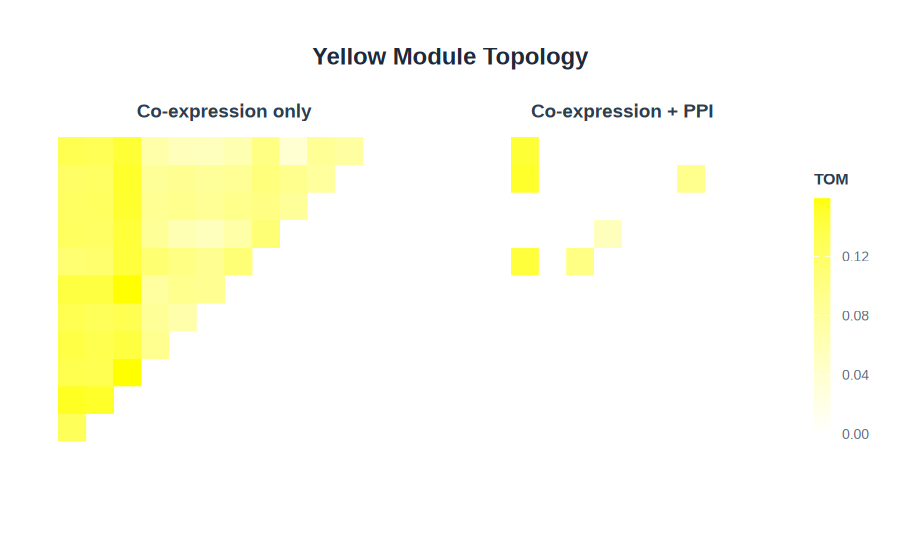

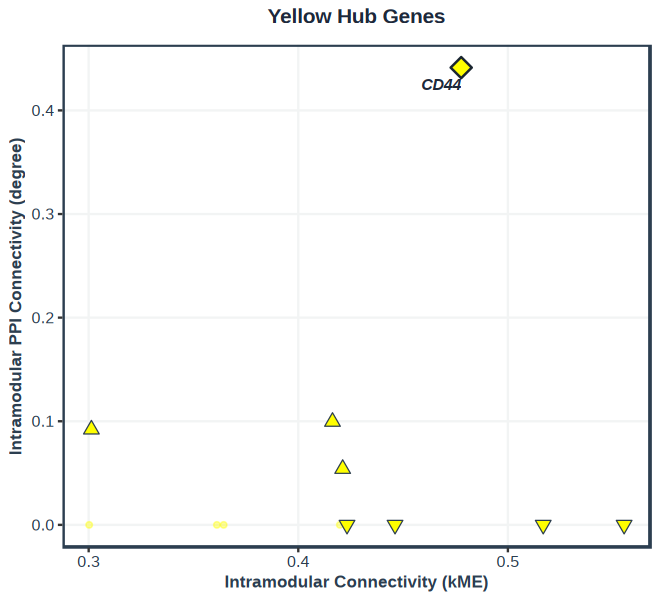

In [10]:
library(ggplot2)
library(dplyr)
library(patchwork)
library(ggrepel)  


options(repr.plot.width = 7.5, repr.plot.height = 4.5) 

cur_mod <- 'yellow'
cur_color <- mod_cp[cur_mod]
formatted_mod_title <- paste0(toupper(substring(cur_mod, 1, 1)), substring(cur_mod, 2))

tmp <- ModuleTopologyHeatmap(
    combined_obj,
    mod = cur_mod,
    matrix = TOM,
    matrix_name = 'TOM',
    order_by = 'kME',
    high_color = cur_color,
    #type = 'unsigned',
    return_genes = TRUE 
) 

subplot_theme <- theme(
  plot.title = element_text(hjust = 0.5, face = "bold", size = 11, color = "#2C3E50", margin = margin(b = 8)),
  plot.margin = margin(t = 6, r = 10, b = 6, l = 10, unit = "pt")
)

p1 <- tmp[[1]] + 
  ggtitle('Co-expression only') + 
  NoLegend() + 
  subplot_theme

gene_list <- tmp[[2]]
p2 <- ModuleTopologyHeatmap(
    combined_obj,
    mod = cur_mod,
    matrix = TOM_ppi,
    matrix_name = 'TOM',
    order_by = 'kME',
    high_color = cur_color,
    #type = 'unsigned',
    plot_max = tmp$plot_max,
    genes_order = gene_list
) + 
  ggtitle('Co-expression + PPI') + 
  subplot_theme +
  theme(
    legend.title = element_text(size = 9, face = "bold", color = "#2C3E50"),
    legend.text = element_text(size = 8, color = "#5D6D7E"),
    legend.key.width = unit(0.35, "cm"),
    legend.key.height = unit(1.0, "cm")
  )

combined_heatmaps <- (p1 | p2) + 
  plot_annotation(
    title = paste(formatted_mod_title, "Module Topology"), 
    theme = theme(
      plot.title = element_text(
        hjust = 0.5, 
        face = "bold", 
        size = 14,             
        color = "#1E293B", 
        margin = margin(t = 10, b = 15) 
      )
    )
  )

combined_heatmaps



options(repr.plot.width = 5.5, repr.plot.height = 5.0) 
cur_genes <- modules %>% subset(module == cur_mod) %>% .$gene_name
kme_df <- GetHubGenes(combined_obj, n_hubs=Inf) %>% subset(gene_name %in% cur_genes)
rownames(kme_df) <- kme_df$gene_name

cur_TOM_ppi <- TOM_ppi[cur_genes, cur_genes] 
cur_TOM_ppi[lower.tri(cur_TOM_ppi)] <- 0 
cur_TOM_df <- reshape2::melt(cur_TOM_ppi) %>% subset(Var1 != Var2)

ppi_degree <- cur_TOM_df %>% 
    dplyr::group_by(Var1) %>% 
    dplyr::summarise(degree = sum(value)) %>%
    dplyr::mutate(weighted_degree = degree / max(degree)) %>%
    dplyr::arrange(-degree) %>% 
    dplyr::rename(gene_name = Var1) %>%
    as.data.frame() 
rownames(ppi_degree) <- ppi_degree$gene_name

kme_df$ppi_degree <- ppi_degree[kme_df$gene_name, 'degree']

n_genes <- 5
top_kme <- kme_df %>% filter(kME>0) %>% slice_max(order_by=kME, n=n_genes) %>% .$gene_name
top_ppi <- kme_df %>% filter(ppi_degree>0) %>% slice_max(order_by=ppi_degree, n=n_genes) %>% .$gene_name

top_both <- intersect(top_kme, top_ppi)
df_kme <- subset(kme_df, gene_name %in% top_kme & !(gene_name %in% top_both))
df_ppi <- subset(kme_df, gene_name %in% top_ppi & !(gene_name %in% top_both))
df_both <- subset(kme_df, gene_name %in% top_both)

v_line <- min(df_kme$kME)
h_line <- min(df_ppi$ppi_degree)
point_size <- 3.0
yellow_df_both <- df_both

kme_df %>% subset(!(gene_name %in% c(top_kme, top_ppi))) %>%
    ggplot(aes(x = kME, y = ppi_degree)) + 
    
    geom_point(color = cur_color, size = 1.2, alpha = 0.4) + 
    
    geom_point(
        data = df_kme, size = point_size,
        fill = cur_color, color = "#2C3E50", stroke = 0.4, shape = 25
    ) + 
    
    geom_point(
        data = df_ppi, size = point_size,
        fill = cur_color, color = "#2C3E50", stroke = 0.4, shape = 24
    ) + 
    
    geom_point(
        data = df_both, size = point_size * 1.4,
        fill = cur_color, color = "#1A2530", stroke = 0.8, shape = 23
    ) + 
    
    geom_text_repel(
        data = df_both,
        mapping = aes(label = gene_name),
        color = "#1E293B",
        size = 3.2,
        fontface = "bold.italic",         
        box.padding = unit(0.4, "lines"), 
        point.padding = unit(0.3, "lines"),
        segment.color = "#7F8C8D",        
        segment.size = 0.4,               
        segment.linetype = "solid",
        max.overlaps = 20
    ) +
    
    labs(
      x = "Intramodular Connectivity (kME)", 
      y = "Intramodular PPI Connectivity (degree)",
      title = paste(formatted_mod_title, "Hub Genes")
    ) + 
    theme_bw(base_size = 11) +
    theme(
        panel.grid.major = element_line(color = "#F2F4F4", size = 0.5), 
        panel.grid.minor = element_blank(),
        panel.border = element_rect(color = "#2C3E50", fill = NA, size = 1.0), 
        axis.text = element_text(color = "#2C3E50", size = 9.5),
        axis.title = element_text(face = "bold", color = "#2C3E50", size = 10),
        plot.title = element_text(hjust = 0.5, face = "bold", size = 12, color = "#1E293B", margin = margin(b = 10)),
        plot.background = element_blank()
    ) 

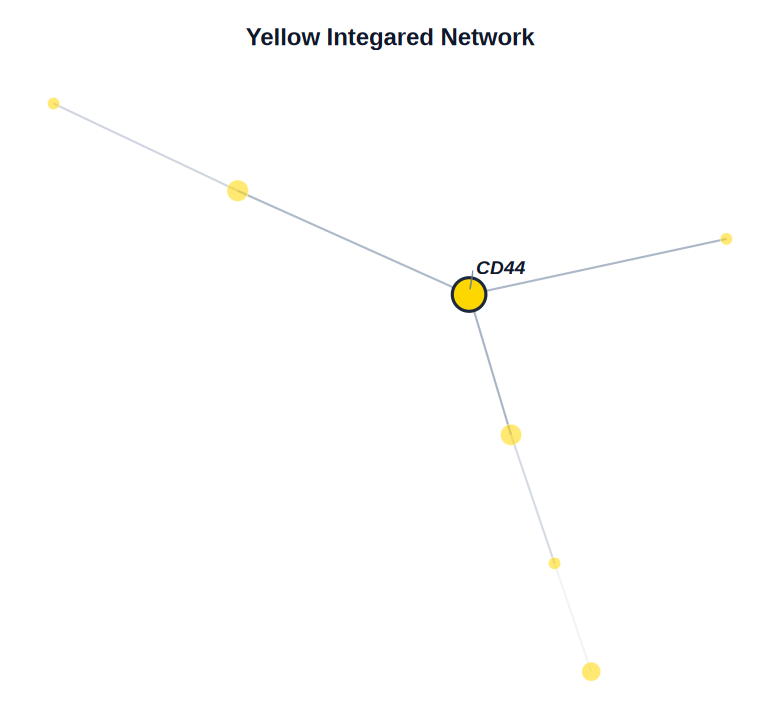

In [11]:
options(repr.plot.width = 6.5, repr.plot.height = 6.0) 
safe_scale01 <- function(x) {
  if (max(x, na.rm = TRUE) == min(x, na.rm = TRUE)) return(rep(1, length(x)))
  return((x - min(x, na.rm = TRUE)) / (max(x, na.rm = TRUE) - min(x, na.rm = TRUE)))
}

plot_list <- list()
mods <- 'yellow'
for (cur_mod in mods) {
    
    cur_genes <- modules %>% subset(module == cur_mod) %>% .$gene_name

    kme_df <- GetHubGenes(combined_obj, n_hubs=Inf) %>%
        subset(gene_name %in% cur_genes)
    rownames(kme_df) <- kme_df$gene_name

    cur_TOM_ppi <- TOM_ppi[cur_genes, cur_genes] 
    cur_TOM_ppi[lower.tri(cur_TOM_ppi)] <- 0 

    cur_TOM_df <- reshape2::melt(cur_TOM_ppi) %>% subset(Var1 != Var2)

    ppi_degree <- cur_TOM_df %>% 
        dplyr::group_by(Var1) %>% 
        dplyr::summarise(degree = sum(value)) %>%
        dplyr::mutate(weighted_degree = degree / max(degree)) %>%
        dplyr::arrange(-degree) %>% 
        dplyr::rename(gene_name = Var1) %>%
        as.data.frame() 
    rownames(ppi_degree) <- ppi_degree$gene_name

    kme_df$ppi_degree <- ppi_degree[kme_df$gene_name, 'degree']

    n_genes <- 5
    top_kme <- kme_df %>% filter(kME>0) %>% slice_max(order_by=kME, n=n_genes) %>% .$gene_name
    top_ppi <- kme_df %>% filter(ppi_degree>0) %>% slice_max(order_by=ppi_degree, n=n_genes) %>% .$gene_name
    top_both <- intersect(top_kme, top_ppi)

    graph <- cur_TOM_ppi %>% 
        reshape2::melt() %>% 
        dplyr::rename(gene1 = Var1, gene2 = Var2, weight=value) %>%
        subset(weight > 0) %>%
        igraph::graph_from_data_frame() %>%
        tidygraph::as_tbl_graph(directed=FALSE) %>% 
        tidygraph::activate(nodes)

    V(graph)$module <- modules[V(graph)$name, 'module']
    V(graph)$hub    <- ifelse(V(graph)$name %in% top_both, V(graph)$name, "")
    V(graph)$kME    <- kme_df[V(graph)$name, 'kME']
    V(graph)$ppi_degree <- kme_df[V(graph)$name, 'ppi_degree']

    ig_obj <- tidygraph::as.igraph(graph)

    coords <- tryCatch({
        igraph::layout_with_fr(ig_obj, weights = NA) 
    }, error = function(e) {
        igraph::layout_nicely(ig_obj)
    })
    
    coords <- scale(coords) * 1.5
    
    lay <- ggraph::create_layout(graph, layout = "manual", x = coords[, 1], y = coords[, 2])

    p <- ggraph(lay) + 
      geom_edge_link(
        aes(edge_alpha = safe_scale01(weight)), 
        color = "#94A3B8",        
        width = 0.45,
        show.legend = FALSE
      ) + 
      scale_edge_alpha_continuous(range = c(0.12, 0.80)) + 
    
      geom_node_point(
        aes(fill = module, size = ppi_degree), 
        shape = 21,
        color = "white",
        stroke = 0.3,
        alpha = 0.55,
        show.legend = FALSE
      ) +
      
      geom_node_point(
        data = subset(lay, hub != ''), 
        aes(fill = module, size = ppi_degree), 
        color = "#1E293B",        
        shape = 21, 
        stroke = 1.0,             
        alpha = 1.0,             
        show.legend = FALSE
      ) +
      
      scale_size_continuous(range = c(3, 8.5)) +
      scale_colour_manual(values = '#FFD700') +
      scale_fill_manual(values = '#FFD700') +
      
      geom_node_label(
        aes(label = hub), 
        repel = TRUE, 
        max.overlaps = 50,                     
        fontface = 'bold.italic',              
        size = 4,                            
        color = "#0F172A",                     
        fill = alpha("white", 0.70),           
        label.size = NA,                       
        label.padding = unit(0.12, "lines"),   
        box.padding = unit(0.65, "lines"),     
        point.padding = unit(0.40, "lines"),   
        segment.color = "#64748B",             
        segment.size = 0.35,
        segment.alpha = 0.8
      ) +
      
      labs(title = paste0(toupper(substring(cur_mod, 1, 1)), substring(cur_mod, 2), " Integared Network")) +
      theme_void() + 
      theme(
        plot.title = element_text(
          hjust = 0.5, 
          face = "bold", 
          size = 14, 
          color = "#0F172A", 
          margin = margin(t = 5, b = 15)
        ),
        plot.margin = margin(t = 12, r = 12, b = 12, l = 12, unit = "pt")
      )

    plot_list[[cur_mod]] <- p
}

plot_list[["yellow"]]


[1] "plot_df:"
    Var1 Var2 value
2   PIGR MUC2     0
3  CLCA1 MUC2     0
4   ZG16 MUC2     0
5   TFF3 MUC2     0
6 SPINK4 MUC2     0
7   REG4 MUC2     0
[1] "plot_df:"
    Var1 Var2 value
2   PIGR MUC2     0
3  CLCA1 MUC2     0
4   ZG16 MUC2     0
5   TFF3 MUC2     0
6 SPINK4 MUC2     0
7   REG4 MUC2     0


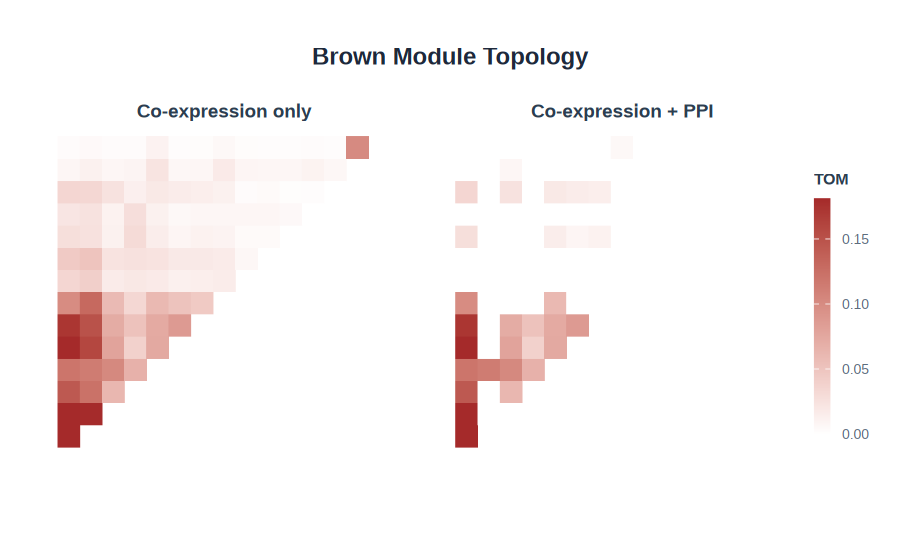

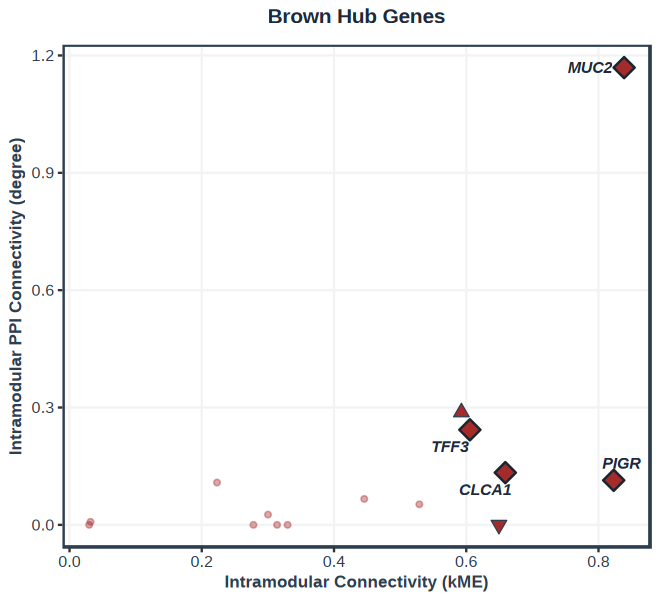

In [12]:

options(repr.plot.width = 7.5, repr.plot.height = 4.5) 

cur_mod <- 'brown'
cur_color <- mod_cp[cur_mod]
formatted_mod_title <- paste0(toupper(substring(cur_mod, 1, 1)), substring(cur_mod, 2))

tmp <- ModuleTopologyHeatmap(
    combined_obj,
    mod = cur_mod,
    matrix = TOM,
    matrix_name = 'TOM',
    order_by = 'kME',
    high_color = cur_color,
   # type = 'unsigned',
    return_genes = TRUE 
) 


subplot_theme <- theme(
  plot.title = element_text(hjust = 0.5, face = "bold", size = 11, color = "#2C3E50", margin = margin(b = 8)),
  plot.margin = margin(t = 6, r = 10, b = 6, l = 10, unit = "pt")
)


p1 <- tmp[[1]] + 
  ggtitle('Co-expression only') + 
  NoLegend() + 
  subplot_theme


gene_list <- tmp[[2]]
p2 <- ModuleTopologyHeatmap(
    combined_obj,
    mod = cur_mod,
    matrix = TOM_ppi,
    matrix_name = 'TOM',
    order_by = 'kME',
    high_color = cur_color,
    #type = 'unsigned',
    plot_max = tmp$plot_max,
    genes_order = gene_list
) + 
  ggtitle('Co-expression + PPI') + 
  subplot_theme +
  theme(
    legend.title = element_text(size = 9, face = "bold", color = "#2C3E50"),
    legend.text = element_text(size = 8, color = "#5D6D7E"),
    legend.key.width = unit(0.35, "cm"),
    legend.key.height = unit(1.0, "cm")
  )

combined_heatmaps <- (p1 | p2) + 
  plot_annotation(
    title = paste(formatted_mod_title, "Module Topology"), 
    theme = theme(
      plot.title = element_text(
        hjust = 0.5, 
        face = "bold", 
        size = 14,             
        color = "#1E293B", 
        margin = margin(t = 10, b = 15) 
      )
    )
  )


combined_heatmaps


options(repr.plot.width = 5.5, repr.plot.height = 5.0) 

cur_genes <- modules %>% subset(module == cur_mod) %>% .$gene_name
kme_df <- GetHubGenes(combined_obj, n_hubs=Inf) %>% subset(gene_name %in% cur_genes)
rownames(kme_df) <- kme_df$gene_name

cur_TOM_ppi <- TOM_ppi[cur_genes, cur_genes] 
cur_TOM_ppi[lower.tri(cur_TOM_ppi)] <- 0 
cur_TOM_df <- reshape2::melt(cur_TOM_ppi) %>% subset(Var1 != Var2)

ppi_degree <- cur_TOM_df %>% 
    dplyr::group_by(Var1) %>% 
    dplyr::summarise(degree = sum(value)) %>%
    dplyr::mutate(weighted_degree = degree / max(degree)) %>%
    dplyr::arrange(-degree) %>% 
    dplyr::rename(gene_name = Var1) %>%
    as.data.frame() 
rownames(ppi_degree) <- ppi_degree$gene_name

kme_df$ppi_degree <- ppi_degree[kme_df$gene_name, 'degree']

n_genes <- 5
top_kme <- kme_df %>% filter(kME>0) %>% slice_max(order_by=kME, n=n_genes) %>% .$gene_name
top_ppi <- kme_df %>% filter(ppi_degree>0) %>% slice_max(order_by=ppi_degree, n=n_genes) %>% .$gene_name

top_both <- intersect(top_kme, top_ppi)
df_kme <- subset(kme_df, gene_name %in% top_kme & !(gene_name %in% top_both))
df_ppi <- subset(kme_df, gene_name %in% top_ppi & !(gene_name %in% top_both))
df_both <- subset(kme_df, gene_name %in% top_both)

v_line <- min(df_kme$kME)
h_line <- min(df_ppi$ppi_degree)
point_size <- 3.0
brown_df_both <- df_both
p_scatter <- kme_df %>% subset(!(gene_name %in% c(top_kme, top_ppi))) %>%
    ggplot(aes(x = kME, y = ppi_degree)) + 
    geom_point(color = cur_color, size = 1.2, alpha = 0.4) + 
    geom_point(
        data = df_kme, size = point_size,
        fill = cur_color, color = "#2C3E50", stroke = 0.4, shape = 25
    ) + 
    geom_point(
        data = df_ppi, size = point_size,
        fill = cur_color, color = "#2C3E50", stroke = 0.4, shape = 24
    ) + 
    geom_point(
        data = df_both, size = point_size * 1.4,
        fill = cur_color, color = "#1A2530", stroke = 0.8, shape = 23
    ) + 
    geom_text_repel(
        data = df_both,
        mapping = aes(label = gene_name),
        color = "#1E293B",
        size = 3.2,
        fontface = "bold.italic",         
        box.padding = unit(0.4, "lines"), 
        point.padding = unit(0.3, "lines"),
        segment.color = "#7F8C8D",        
        segment.size = 0.4,               
        segment.linetype = "solid",
        max.overlaps = 20
    ) +
    labs(
      x = "Intramodular Connectivity (kME)", 
      y = "Intramodular PPI Connectivity (degree)",
      title = paste(formatted_mod_title, "Hub Genes")
    ) + 
    theme_bw(base_size = 11) +
    theme(
        panel.grid.major = element_line(color = "#F2F4F4", size = 0.5), 
        panel.grid.minor = element_blank(),
        panel.border = element_rect(color = "#2C3E50", fill = NA, size = 1.0),
        axis.text = element_text(color = "#2C3E50", size = 9.5),
        axis.title = element_text(face = "bold", color = "#2C3E50", size = 10),
        plot.title = element_text(hjust = 0.5, face = "bold", size = 12, color = "#1E293B", margin = margin(b = 10)),
        plot.background = element_blank()
    ) 
p_scatter



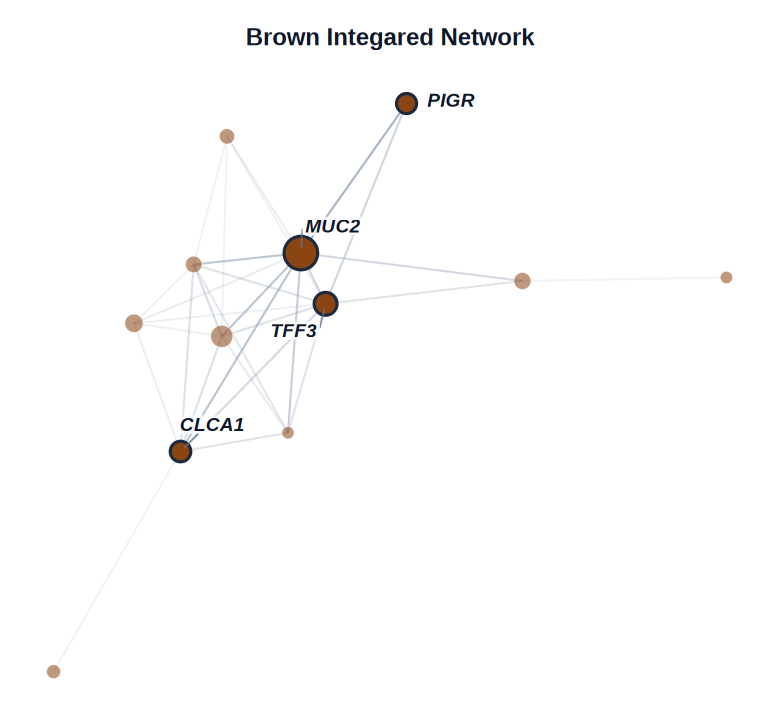

In [13]:
options(repr.plot.width = 6.5, repr.plot.height = 6.0) 

safe_scale01 <- function(x) {
  if (max(x, na.rm = TRUE) == min(x, na.rm = TRUE)) return(rep(1, length(x)))
  return((x - min(x, na.rm = TRUE)) / (max(x, na.rm = TRUE) - min(x, na.rm = TRUE)))
}

plot_list <- list()
mods <- 'brown'
for (cur_mod in mods) {
    
    cur_genes <- modules %>% subset(module == cur_mod) %>% .$gene_name

    kme_df <- GetHubGenes(combined_obj, n_hubs=Inf) %>%
        subset(gene_name %in% cur_genes)
    rownames(kme_df) <- kme_df$gene_name

    cur_TOM_ppi <- TOM_ppi[cur_genes, cur_genes] 
    cur_TOM_ppi[lower.tri(cur_TOM_ppi)] <- 0 

    cur_TOM_df <- reshape2::melt(cur_TOM_ppi) %>% subset(Var1 != Var2)

    ppi_degree <- cur_TOM_df %>% 
        dplyr::group_by(Var1) %>% 
        dplyr::summarise(degree = sum(value)) %>%
        dplyr::mutate(weighted_degree = degree / max(degree)) %>%
        dplyr::arrange(-degree) %>% 
        dplyr::rename(gene_name = Var1) %>%
        as.data.frame() 
    rownames(ppi_degree) <- ppi_degree$gene_name

    kme_df$ppi_degree <- ppi_degree[kme_df$gene_name, 'degree']

    n_genes <- 5
    top_kme <- kme_df %>% filter(kME>0) %>% slice_max(order_by=kME, n=n_genes) %>% .$gene_name
    top_ppi <- kme_df %>% filter(ppi_degree>0) %>% slice_max(order_by=ppi_degree, n=n_genes) %>% .$gene_name
    top_both <- intersect(top_kme, top_ppi)

    graph <- cur_TOM_ppi %>% 
        reshape2::melt() %>% 
        dplyr::rename(gene1 = Var1, gene2 = Var2, weight=value) %>%
        subset(weight > 0) %>%
        igraph::graph_from_data_frame() %>%
        tidygraph::as_tbl_graph(directed=FALSE) %>% 
        tidygraph::activate(nodes)

    V(graph)$module <- modules[V(graph)$name, 'module']
    V(graph)$hub    <- ifelse(V(graph)$name %in% top_both, V(graph)$name, "")
    V(graph)$kME    <- kme_df[V(graph)$name, 'kME']
    V(graph)$ppi_degree <- kme_df[V(graph)$name, 'ppi_degree']

    ig_obj <- tidygraph::as.igraph(graph)

    coords <- tryCatch({
        igraph::layout_with_fr(ig_obj, weights = NA) 
    }, error = function(e) {
        igraph::layout_nicely(ig_obj)
    })
    
    coords <- scale(coords) * 1.5
    
    lay <- ggraph::create_layout(graph, layout = "manual", x = coords[, 1], y = coords[, 2])

    p <- ggraph(lay) + 
      geom_edge_link(
        aes(edge_alpha = safe_scale01(weight)), 
        color = "#94A3B8",       
        width = 0.45,
        show.legend = FALSE
      ) + 
      scale_edge_alpha_continuous(range = c(0.12, 0.80)) + 
      geom_node_point(
        aes(fill = module, size = ppi_degree), 
        shape = 21,
        color = "white",
        stroke = 0.3,
        alpha = 0.55,
        show.legend = FALSE
      ) +
      geom_node_point(
        data = subset(lay, hub != ''), 
        aes(fill = module, size = ppi_degree), 
        color = "#1E293B",        
        shape = 21, 
        stroke = 1.0,             
        alpha = 1.0,              
        show.legend = FALSE
      ) +
    
      scale_size_continuous(range = c(3.0, 8.5)) +
      scale_colour_manual(values = '#8B4513') +
      scale_fill_manual(values = '#8B4513') +
      geom_node_label(
        aes(label = hub), 
        repel = TRUE, 
        max.overlaps = 50,                     
        fontface = 'bold.italic',              
        size = 4,                           
        color = "#0F172A",                     
        fill = alpha("white", 0.70),           
        label.size = NA,                       
        label.padding = unit(0.12, "lines"),   
        box.padding = unit(0.65, "lines"),     
        point.padding = unit(0.40, "lines"),   
        segment.color = "#64748B",             
        segment.size = 0.35,
        segment.alpha = 0.8
      ) +
      
      labs(title = paste0(toupper(substring(cur_mod, 1, 1)), substring(cur_mod, 2), " Integared Network")) +
      theme_void() + 
      theme(
        plot.title = element_text(
          hjust = 0.5, 
          face = "bold", 
          size = 14, 
          color = "#0F172A", 
          margin = margin(t = 5, b = 15)
        ),
        plot.margin = margin(t = 12, r = 12, b = 12, l = 12, unit = "pt")
      )

    plot_list[[cur_mod]] <- p
}

plot_list[["brown"]]




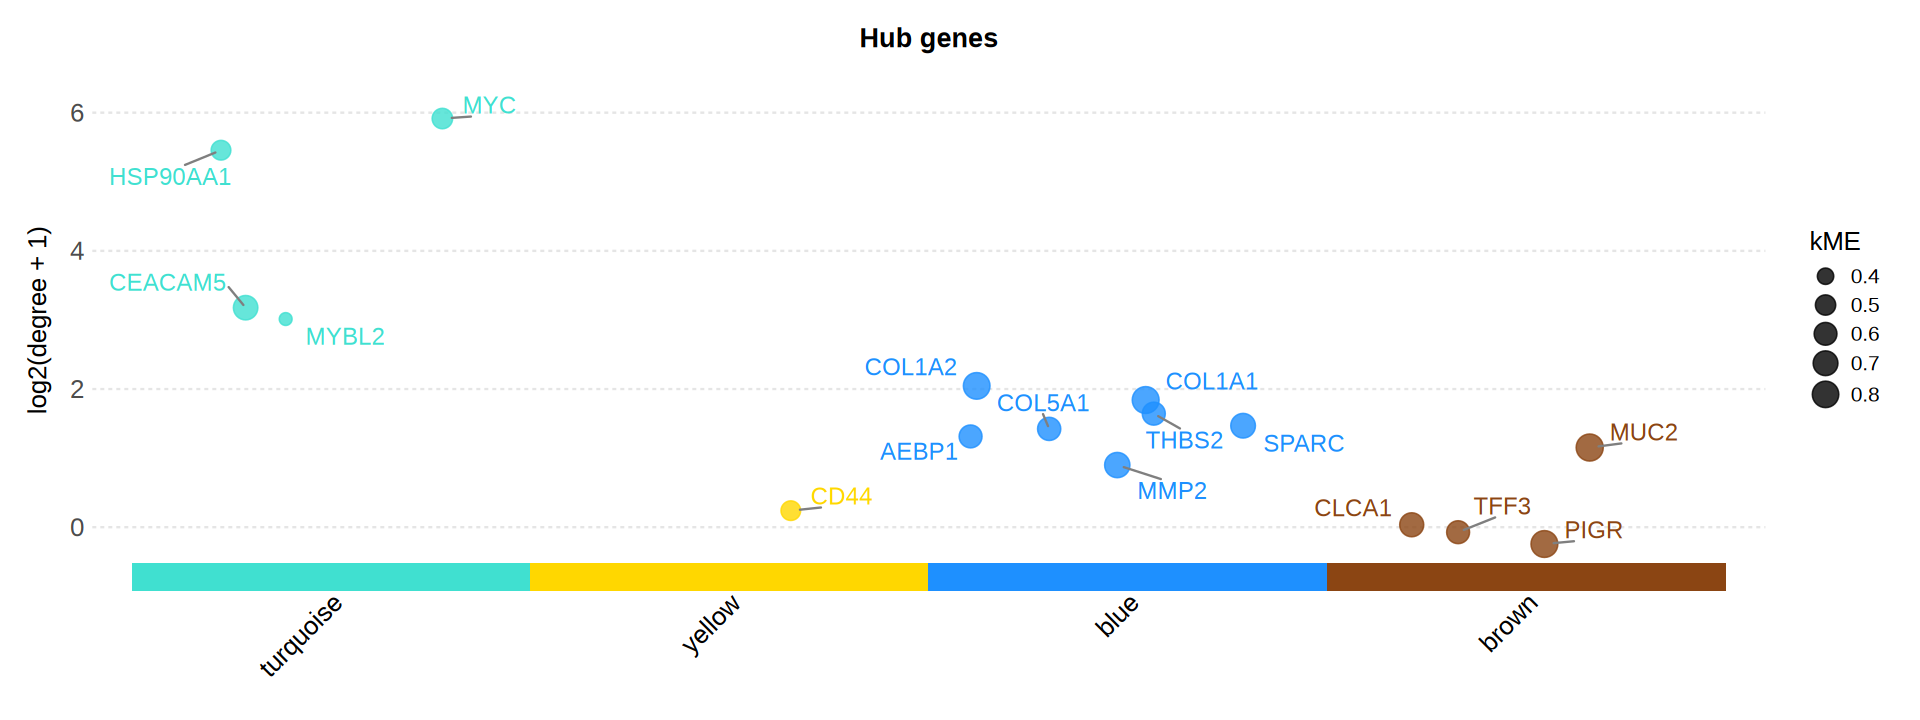

In [14]:
# Fig 3C
options(repr.plot.width = 16, repr.plot.height = 6) 
hub_genes_data_raw <- rbind(brown_df_both,blue_df_both,yellow_df_both,turquoise_df_both)

module_order <- c("turquoise", "yellow", "blue", "brown")
hub_genes_data_raw$module <- factor(hub_genes_data_raw$module, levels = module_order)

hub_genes_metrics <- hub_genes_data_raw %>%
  mutate(log2_ppi_degree = log2(ppi_degree + 1))


module_df <- data.frame(module = module_order)
module_df$module <- factor(module_df$module, levels = module_order)


module_colors <- c("brown" = "#8B4513",     
                   "blue" = "#1E90FF",      
                   "yellow" = "#FFD700",    
                   "turquoise" = "#40E0D0") 



jitter_pos <- position_jitter(width = 0.4, seed = 2026,height = 0.4) 



p_main_scatter <- ggplot(hub_genes_metrics, aes(x = module, y = log2_ppi_degree, size = kME, color = module)) +

  geom_point(position = jitter_pos, alpha = 0.8) + 
  
  geom_text_repel(aes(label = gene_name, color = module),
                  position = jitter_pos, 
                  box.padding = 0.7,       
                  point.padding = 0.6,     
                  size = 5,                
                  max.overlaps = Inf,      
                  segment.color = 'grey50',
                  show.legend = FALSE
                  ) +
  
  scale_color_manual(values = module_colors, guide = "none") +
  scale_size_continuous(name = "kME", range = c(3, 7)) +
  scale_y_continuous(breaks = seq(0, 6, by = 2), limits = c(-0.5, 6.5), expand = c(0, 0)) +
  labs(
    x = NULL,
    y = "log2(degree + 1)",
    title = "Hub genes"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 16, margin = margin(b = 15)),
    axis.title.y = element_text(size = 15, margin = margin(r = 10)),
    axis.text.y = element_text(size = 15),
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.major.y = element_line(color = "grey90", linetype = "dashed"),
    panel.grid.minor = element_blank(),
    plot.margin = margin(t = 10, r = 10, b = 0, l = 10, unit = "pt"),
    legend.position = "right",
    legend.title = element_text(size = 15),
    legend.text = element_text(size = 12),
    legend.box.margin = margin(t = 0, r = 0, b = 0, l = 10)
  )

p_module_strip <- ggplot(module_df, aes(x = module, fill = module)) +
  geom_tile(aes(y = 0.5), height = 0.4) +
  scale_fill_manual(values = module_colors) +
  labs(x = NULL, y = NULL) +
  theme_void() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = 15, color = "black"), 
    plot.margin = margin(t = 0, r = 10, b = 10, l = 10, unit = "pt"),
    legend.position = "none"
  )


p_main_scatter / p_module_strip + plot_layout(heights = c(8, 0.5))

In [15]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 16.04.6 LTS

Matrix products: default
BLAS/LAPACK: /home/amax/.local/share/mamba/envs/hdWGCNA2/lib/libopenblasp-r0.3.32.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8           LC_NUMERIC=C              
 [3] LC_TIME=zh_CN.UTF-8        LC_COLLATE=C              
 [5] LC_MONETARY=zh_CN.UTF-8    LC_MESSAGES=C             
 [7] LC_PAPER=zh_CN.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=zh_CN.UTF-8 LC_IDENTIFICATION=C       

time zone: Asia/Shanghai
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] ggrastr_1.0.2               STRINGdb_2.14.3            
 [3] hdWGCNA_0.4.11              enrichR_3.4                
 [5] SummarizedExperiment_1.32.0 Biobase_2.62.0             
 [7] MatrixGenerics